## Outcome devaluation and habit expression
Here I want to take a different approach, compared to previous experiment, where we actually model a two-stage trial. This allows me to look at the role of planning and talk about habituation of sequences.

In this paper authors showed that when you train two actions concurrently (need to still define this group in terms of simulation parameters and make some predictions about what will happen), neither of them gets expressed as habit. When you train and devalue only 1, you can show a habit. I will try and recreate the simulations. 

![alt text](img1_exp_design.png)


### Group 1 - has 1 action 

Environment:
Reward contingenciesrepresent the probability of outcomes O1, O2 or ~O given actions A1 or ~A1 and are as follows during training and extinction, respectivelly:


\begin{bmatrix} 0.9  & 0   \\ 0    & 0.5  \\ 0.1  & 0.5 \end{bmatrix}, \begin{bmatrix} 0  & 0   \\ 0  & 0  \\ 1  & 1 \end{bmatrix}



During training the outcome preference $p(\bar{o})$ is $\left[0.45,0.45,0.1\right]$ and during devaluation we have 2 groups, one where the habit-associated outcome is devalued and one where the non-contingent outcome is devalued:

$p(\bar{o}_{h})=\left[0.1,0.8,0.1\right]$, $p(\bar{o}_{n})=\left[0.8,0.1,0.1\right]$

I can explore here building habit only over 1 action!

### Group 2 - has 2 actions


Environment:
Reward contingenciesrepresent the probability of outcomes O1, O2 or ~O given actions A1, A2 or ~A and are as follows during training and extinction, respectivelly:


\begin{bmatrix} 0.9  & 0    & 0    \\ 0    & 0.9  & 0    \\ 0.1  & 0.1 & 1 \end{bmatrix}, \begin{bmatrix} 0  & 0   & 0   \\ 0  & 0  & 0   \\ 1  & 1 & 1   \end{bmatrix}



During training the outcome preference $p(\bar{o})$ is $\left[0.45,0.45,0.1\right]$ and during devaluation we again have 2 groups, with $p(\bar{o}_{h})=\left[0.1,0.8,0.1\right]$, $p(\bar{o}_{n})=\left[0.8,0.1,0.1\right]$


This is the pattern of behaviour from the paper:

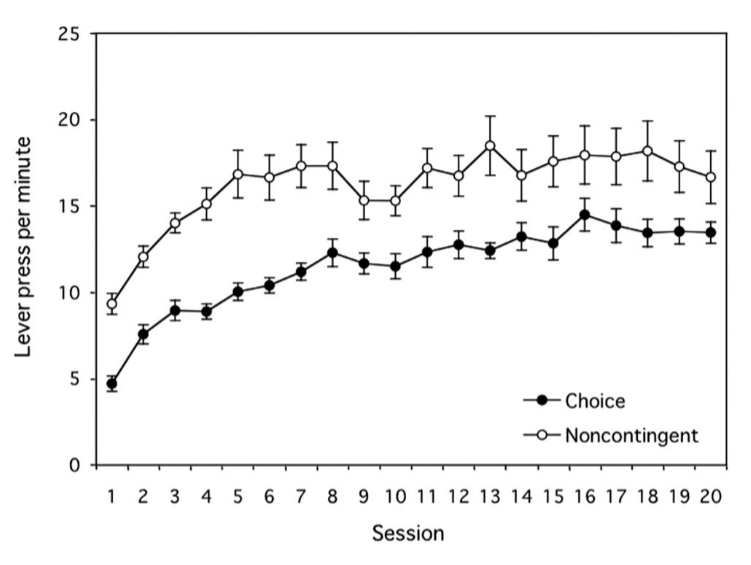

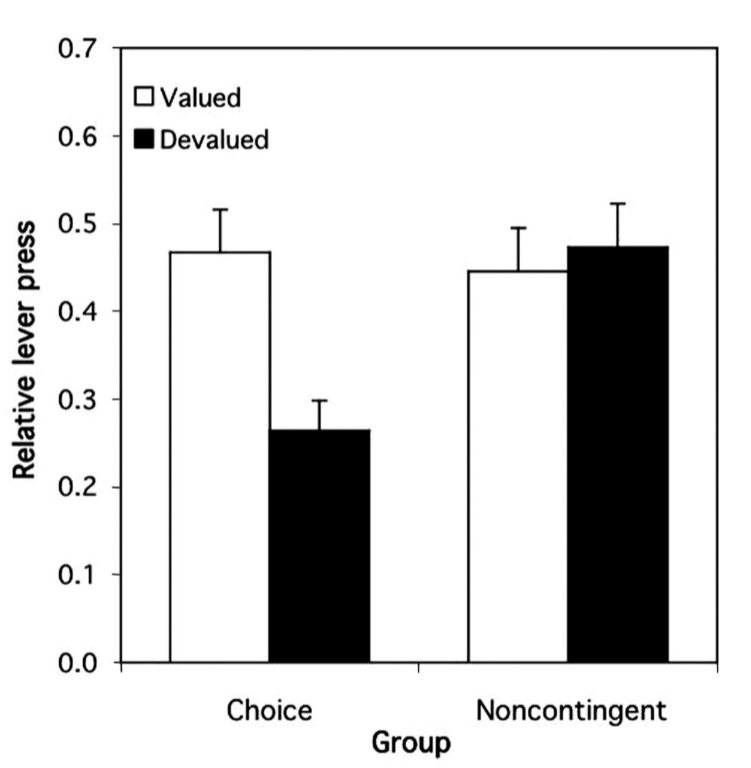



## Group 1 no habit

In the first version of this I set it up where the agent only learns to associate reward with the state of entering magazine. This of course does not work, because policies that say visit magazine as much as possible dominate, because animal does not learn the contingency between action and reward. In order to achieve this I need to add another state for the magazine, effectively defining a full and empty magazine and potentially also learn pertinent state transitions.

So, in the code I need to:

1. Expand state transition matrix to something like this. Optimally the agent learns the probability of transitioning into an empty or full magazine depending on action or 

a = L1
	L1 ~L1 MF ME IS
 L1 1   1  1  1   1
~L1 0   0  0  0   0
 ME 0   0  0  0   0
 MF 0   0  0  0   0
 IS 0   0  0  0   0

a = ~L1
	L1 ~L1 MF ME IS
 L1 0   0  0  0   0
~L1 1   1  1  1   1
 ME 0   0  0  0   0
 MF 0   0  0  0   0
 IS 0   0  0  0   0

a = M
	L1   ~L1   MF ME IS
 L1 0     0    0  0   0
~L1 0     0    0  0   0
 ME 0.5   0.5  1  1   1
 MF 0.5   0.5  0  0   0
 IS 0     0    0  0   0

 
 

In [ ]:
# %matplotlib widget
import matplotlib.pyplot as plt
# import ipywidgets
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def	 __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 habit_exception = None,
				 learn_state_transitions = True,
				 transitions_to_learn = ["magazine_empty", "magazine_full"]
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.action_mapping = env.action_mapping
		self.reward_mapping = env.reward_mapping
		self.state_mapping = env.state_mapping
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations
		self.habit_exception=habit_exception

		self.state_transition_matrix = state_transition_matrix
		
		self.learn_state_transitions = learn_state_transitions # if learning transitions to some stae
		self.transitions_to_learn = transitions_to_learn       # transitions to what states are being learned
		
		if self.learn_state_transitions:
			self.transition_counts = np.ones([TAU,T, len(self.transitions_to_learn), self.ns, self.nc])
		
		self.latest_transition_counts = self.transition_counts[0,0,:,:,:]
	
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])

		self.observation_generation_matrix = observation_generation_matrix
		self.post_norms = np.zeros([self.TAU, self.T, self.T, self.npi, self.nc])

	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,:]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility


		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u,c])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u,c]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u,c])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):

		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
		
 		# print("\n")
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

				# print(tau,t,pi,c)
				# print(self.fwd_messages[:,:,pi,c])
		joint_post = np.zeros([self.ns, self.ns, self.T-1, self.npi, self.nc])
  
		for tt in range(self.T-1):
			for c in range(self.nc):
				for pi in range(self.npi):
					action = self.policies[pi][tt]
					joint_post[:,:,tt,pi,c] = (self.state_transition_matrix[:,:,action,c]*self.fwd_messages[None,:,tt,pi,c])*\
											 self.bwd_messages[:,None,tt+1,pi,c]*\
											 self.obs_messages[:,None,tt+1,pi,c]*\
											 self.reward_messages[:,None,tt+1,pi,c]*\
											 self.obs_messages[None,:,tt,pi,c]*\
											 self.reward_messages[None,:,tt,pi,c]
					# if (pi == 2) and (t==1):		

		joint_post /= joint_post.sum(axis=(0,1))[None, None,:,:,:]
		# print("here",tau,t)
		# for tt in range(self.T-1):
		# 	for pi in range(self.npi):
		# 			print(tau,tt, pi,0)
		# 			print(joint_post[:,:,tt,pi,0])
		# 			if np.all (np.isnan(joint_post[:,:,tt,pi,0])):
		# 				print("nan detected")

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		# post[:,t,:,:] /= post[:,t,:,:].sum(axis=0)
		self.post_norms[tau,t] = post_norm
		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post, np.nan_to_num(joint_post)
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies


	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		pol_ind = self.linear_ind(self.actions[tau])
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()

		if pol_ind != self.habit_exception: 
			alphas_prime[pol_ind,:] += posterior_context
			
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs_prior_states(self,t,tau,posterior_states, posterior_policies, posterior_context):
	 
		if self.actions[tau,t-1] == self.action_mapping["magazine_entry"]:
			
			indexes = [self.state_mapping[transition] for transition in self.transitions_to_learn]
			post = (posterior_states[:,:,t-1,:,:]*posterior_policies[None,None,:,:]*posterior_context[None,None,None,:]).sum(axis=2)#.transpose(1,0,2)
			self.latest_transition_counts += post[indexes,:]
			self.transition_counts[tau,t] = self.latest_transition_counts.copy()
			state_transition_matrix = self.state_transition_matrix.copy()
			state_transition_matrix[indexes,:,self.action_mapping["magazine_entry"],:] = self.latest_transition_counts
			# state_transition_matrix[indexes,:,self.action_mapping["magazine_entry"],:]  /= self.latest_transition_counts.sum(axis=0)
			state_transition_matrix /= state_transition_matrix.sum(axis=0)
   
			return state_transition_matrix


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states, joint_posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)

		if t > 0 and action == self.action_mapping["magazine_entry"]:

			self.state_transition_matrix = self.update_beliefs_prior_states(t, tau, joint_posterior_states, posterior_policies, posterior_context)

		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")
			# print(self.env.magazine_state)

			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies)#.round(7))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies)#.round(7))
			
			print(f"\nposterior_context:")
			print(posterior_context)#.round(7))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")


	def sample_action(self,t,tau):
		# try:
		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
   
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				 state_mapping = {"lever_press":0, "no_lever_press":1, "magazine_empty":2, "magazine_full":3, "initial_state":4},
				 reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
				 action_mapping = {"lever_press":0, "no_lever_press":1, "magazine_entry":2},
 				 rho_noncontingent = 0.3,
	 			#  magazine_state_ind = 2,
				#  no_reward_outcome_ind = 2,
				#  noncontingent_outcome_ind = 1,
				):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.ns = self.B.shape[0]
		self.B_magazine_full = state_transition_matrix.copy()
		self.B_magazine_empty = state_transition_matrix.copy()
		# self.B_magazine_empty[2:4,0:2,-1] = np.array([[1,1],[0,0]])
		# self.B_magazine_full[2:4,0:2,-1] = np.array([[0,0],[1,1]])
		self.B_magazine_empty[2:4,:,-1] = np.array([[1]*self.ns,[0]*self.ns])
		self.B_magazine_full[2:4,:,-1]  = np.array([[0]*self.ns,[1]*self.ns])
		# print(self.B_magazine_empty[:,:,-1])
		# print(self.B_magazine_full[:,:,-1])
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.ones([TAU,T],dtype=int)*reward_mapping["no_reward"]
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits
		self.nb = n_bandits

		self.rho_noncontingent = rho_noncontingent
		self.reward_mapping = reward_mapping
		self.state_mapping = state_mapping
		self.action_mapping = action_mapping
		self.reinforcement = np.zeros(TAU)
		self.magazine_state = np.ones([TAU,T], dtype=int)*self.reward_mapping["no_reward"]

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state, action):
		regime = self.training_protocol[tau]		

		reward = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		
		if t == 0:
			# distribute initial state reward
			self.rewards[tau,t] = reward
		else:
			try:
				# load magazine for next trial
				if reward == self.reward_mapping["outcome_1"]:
					self.magazine_state[tau,t+1] = reward
			except:
				pass                                   # ignore if this was last decision point
			
			# if state == self.state_mapping["magazine_entry"]:
			# 	self.rewards[tau,t] = self.magazine_state[tau,t]

			# if entering magazine get available reward, if not, receive no reward
			if action == self.action_mapping["magazine_entry"]:
				self.rewards[tau,t] = self.magazine_state[tau,t]
			else:
				self.rewards[tau,t] = self.reward_mapping["no_reward"]

		# print("\n", tau,t)
		# print(f"action: {action}, state: {state}, reward: {self.rewards[tau,t]}")
		# print(self.magazine_state[tau])
		return self.rewards[tau,t]


	def noncontingent_reinforcement(self,tau):
		regime = self.training_protocol[tau]
		if regime == 0:
			self.reinforcement[tau] = np.random.uniform() <= self.rho_noncontingent

			if self.reinforcement[tau] == 1:
				self.magazine_state[tau,self.T-1] = self.reward_mapping["outcome_2"]


	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action


		if self.magazine_state[tau,t] != self.reward_mapping["no_reward"] and action == self.action_mapping["magazine_entry"]:
			B = self.B_magazine_full
		else:
			B = self.B_magazine_empty
		
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=B[:,self.states[tau, t-1], action])
		
		# if self.states[tau,t] == 2 and self.magazine_state[tau,t] != self.reward_mapping["no_reward"]:
			# print("\n", tau,t)
			# print(f"action: {action}, state: {self.states[tau,t]}, magazine:{self.magazine_state[tau,t]}")
   
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau):
		self.states[tau,0] = self.state_mapping["initial_state"]
		return self.states[tau,0]


class World():


	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr


	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]


	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau)
					self.environment.noncontingent_reinforcement(tau)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state, action)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)


def run_simulation(h=1000, 
				   n_train = 20,
				   n_extinction = 5, 
				#    rep=1, 
				   na=3, 
				   nb=1, 
				   ns=3, 
				#    no=3, 
				   nr=4, 
				   nc=2, 
				   T=2, 
				   approx_pred_pol = True, 
				   approx_pred_rew = True,
				   utility = [[0.45,0.45, 0.01], [0.8, 0.1, 0.1]], #[[0.45,0.45, 0.01], [0.1,0.8, 0.1]],
				   Rho = None, 
				   debug=False, 
				   context_volatility=0.98, habit_exception=None):
	
	TAU = n_train + n_extinction

	'''           define policies            '''
	npi = na**(T-1)
	nb = nb
	# ns = na+1


	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1,c)      '''
	prior_states = np.array([0]*(ns-1) + [1])[:,None]# np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(ns)]*(ns)).transpose([1,0,2])[:,:,:na]
	state_transition_matrix[2:4,:,-1] = 0.5
	state_transition_matrix = np.stack([state_transition_matrix, state_transition_matrix], axis=-1)
	# print(state_transition_matrix.shape)
	# for a in range(na):
	# 	print(state_transition_matrix[:,:,a,0])
	# 	print(state_transition_matrix[:,:,a,1],"\n")

	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.2, size = counts_prior_rewards.shape)


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.99] + [1-0.99]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	training_protocol = [0]*n_train + [1]*n_extinction

	Rho = Rho[:,:,training_protocol]

	utilities =  np.zeros([TAU,nr])
	utilities[:n_train,:-1] = np.array(utility[0])[None, :]
	utilities[n_train:,:-1] = np.array(utility[1])[None, :]

	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix[:,:,:,0],
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = na,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=ns)

	agent = Agent(
			state_transition_matrix,
			utilities,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			habit_exception=habit_exception
			)

	world = World(agent, env)
	world.agent.context_volatility = context_volatility
	world.agent.h = h
	world.simulate_experiment()

	return world 


def create_dataframe(TAU,T,world):
		agent = world.agent
			# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards.flatten()#world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,:T-1] = world.agent.actions
		action_arr = action_arr.flatten()
		policy_arr = np.full((TAU,T), np.nan)
		policy_arr = np.ravel_multi_index(world.agent.actions.T, (3,3)).repeat(T)
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(T)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		reinforcement_arr = world.environment.reinforcement.repeat(T)
		magazine_state_arr = world.environment.magazine_state.flatten()
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surprise_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surprise_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for s in range(agent.ns):
				reward_prior_arr[f"reward_s{s}_c{c}"] = agent.prior_rewards[:,:,1,s,c].flatten()
	
			for pi in range(agent.npi):
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"policy": policy_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			"reinforcement": reinforcement_arr,
			"magazine_state": magazine_state_arr,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surprise_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		return pd.DataFrame(long_df_dict)

    

C:\Users\Admin\AppData\Local\Temp\ipykernel_19560\4074954943.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.xaxis.set_ticklabels(policy_mapping, rotation=45)


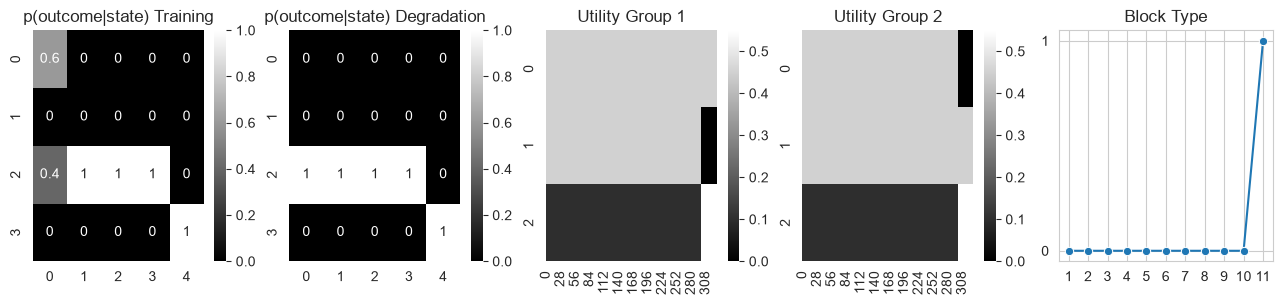

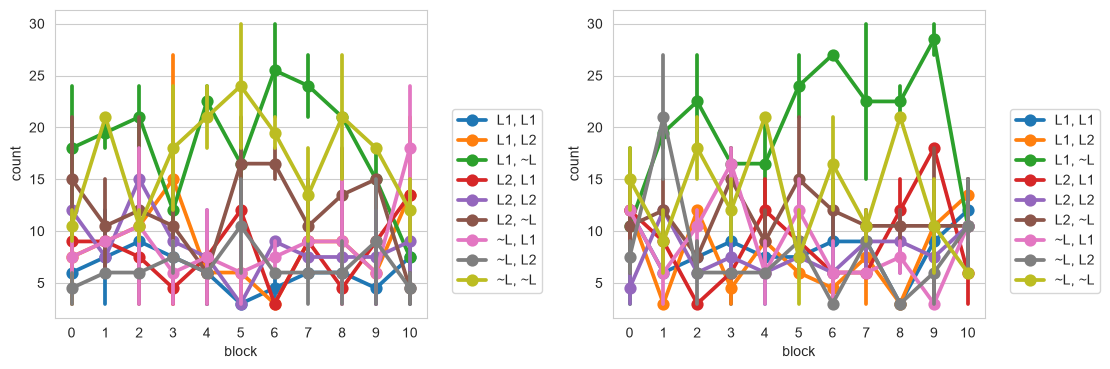

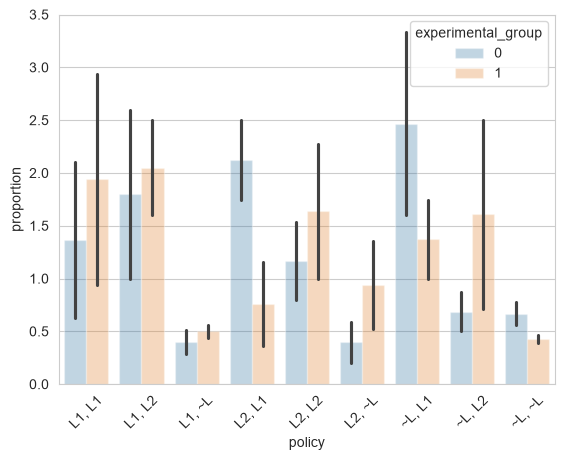

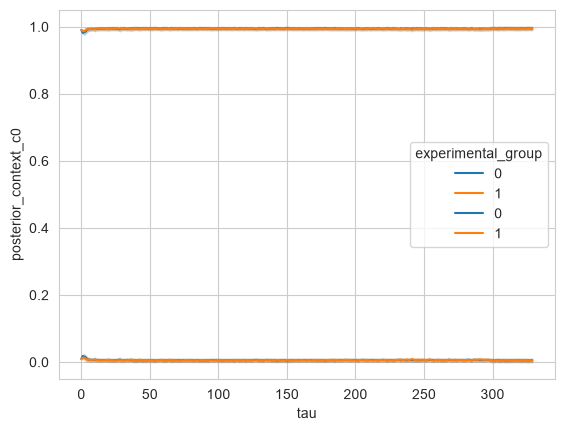

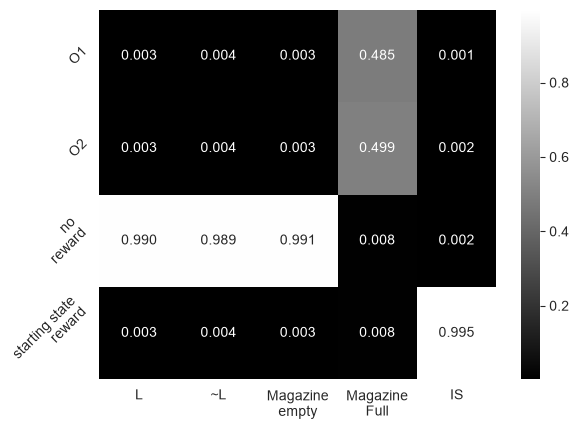

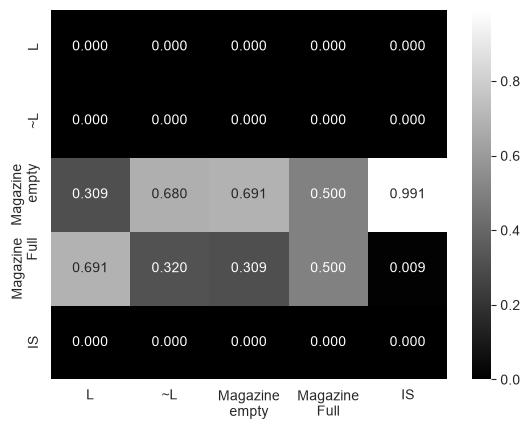

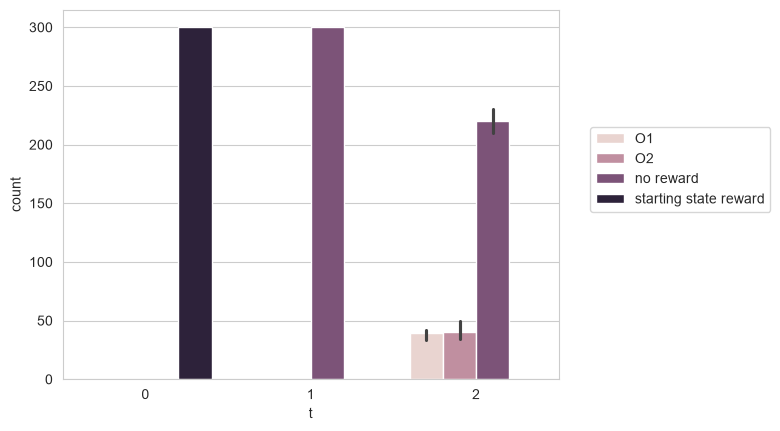

In [ ]:

#######################################################
np.random.seed(6)
reps = 2
n_blocks_train = 10
n_blocks_extinction = 1
block_length = 30

n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length
TAU = n_train + n_extinction
T = 3  # initial time point, action 1, action 2
na = 3 # L1, ~L1, magazine entry
ns = 5 # L1, ~L1, empty magazine, full magazine, initial state
nr = 4 # pellet, sugar, no reward, initial state

p = 0.45
rho_noncontingent = 0.2
rho = 0.6
context_volatility=0.99
h= 1000

utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]

# outcomes: O1=pellets, O2=sugar, O3= no reward, O4=starting outcome, probably don't really need it
# states: L1, ~L1, magazine entry, initial state in front lever
Rho = np.stack([[[rho  , 0.0, 0.0, 0.0, 0.0],
				 [0    , 0.0, 0.0, 0.0, 0.0],
				 [1-rho, 1.0, 1.0, 1.0, 0.0],
				 [0.0  , 0.0, 0.0, 0.0, 1.0]],
				[[0, 0, 0, 0, 0],
				 [0, 0, 0, 0, 0],
				 [1, 1, 1, 1, 0],
				 [0, 0, 0, 0, 1]]], axis=-1)


habit_exception = None
long_dfs = []
matrices = {"state_transition_matrix": np.zeros([ns,ns,reps*2]), "reward_generation_matrix": np.zeros([nr,ns,reps*2])}
sim = 0

for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):
   
		world = run_simulation(debug=False, utility=util, na=na, ns=ns, T=T, n_train=n_train, n_extinction=n_extinction,\
							   Rho=Rho, context_volatility=context_volatility,h=h, habit_exception=habit_exception)

		training_protocol = world.environment.training_protocol

		# Create long format dataframe
		long_df = create_dataframe(TAU,T, world)
		long_dfs.append(long_df)

		
		matrices["state_transition_matrix"][:,:,sim] = world.agent.state_transition_matrix[:,:,-1,0]
		matrices["reward_generation_matrix"][:,:,sim] = world.agent.prior_rewards[-1,-1,:,:,0]
		sim += 1



for key, matrix in matrices.items():
    matrices[key] = matrix.mean(axis=-1)

dataframe = pd.concat(long_dfs)
fig, axes = plt.subplots(1,5,figsize=(16,3))

sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")

sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[2])
sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[3])


sns.lineplot(ax=axes[4], x=np.arange(n_blocks_train + n_blocks_extinction)+1,y=[0]*n_blocks_train + [1]*n_blocks_extinction,marker="o")
axes[4].xaxis.set_major_locator(MultipleLocator(1))
axes[4].yaxis.set_major_locator(MultipleLocator(1))

for ax, title in zip(axes, ["p(outcome|state) Training","p(outcome|state) Degradation", "Utility Group 1", "Utility Group 2", "Block Type"]):
	ax.set_title(title)

##################################################
# Policy labels
action_labels = ["L", "~L", "ME"]
policy_mapping = []
counter = 0
for i in range(na):
	for j in range(na):
		policy_mapping.append(f"{action_labels[i]}, {action_labels[j]}")

"""	Policy execution in each block for whole experiment """
df = dataframe.copy()
df = df.groupby(["experimental_group","sim","block"])["policy"].value_counts().reset_index()
plt.figure(figsize=(12,4))
for group in [0,1]:
	plt.subplot(1,2,group+1)
	g = sns.pointplot(data=df.query(f"experimental_group == {group}"), x="block", y="count", hue="policy", palette="tab10", errorbar="se")
	g.legend(handles=g.get_legend_handles_labels()[0], labels=policy_mapping, bbox_to_anchor=(1.05,0.7))
plt.subplots_adjust(wspace=0.5)


""""    Relative policy execution in two groups"""
df = dataframe.copy()
df = df.groupby(["experimental_group","sim","phase"])["policy"].value_counts(normalize=True)
relative_policy_frequency = (df.loc[:, :, "extinction",:] / df.loc[:, :, "training",:]).reset_index()
# relative_policy_frequency
plt.figure()
g = sns.barplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", errorbar="se", alpha=0.3)
# sns.stripplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", alpha=0.7)
g.xaxis.set_ticklabels(policy_mapping, rotation=45)


"""     Inferred posterior over contexts """

df = dataframe.copy()
plt.figure()
sns.lineplot(data=df, x="tau", y="posterior_context_c0", hue="experimental_group", errorbar="sd")
sns.lineplot(data=df, x="tau", y="posterior_context_c1", hue="experimental_group", errorbar="sd")

"""      Learned reward distribution     """
plt.figure()
g = sns.heatmap(data=matrices["reward_generation_matrix"], annot=True, cmap="gray", fmt=".3f")
# g.set_xlabel.ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
g.yaxis.set_ticklabels(["O1","O2","no\nreward", "starting state\nreward"], rotation=45)
g.xaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])

"""     Learned state transition       	"""
plt.figure()
g = sns.heatmap(matrices["state_transition_matrix"], annot=True, cmap="gray", fmt=".3f")
# g.set_xlabel.ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
# g.yaxis.set_ticklabels(["O1","O2","no\nreward", "starting state\nreward"], rotation=45)
g.xaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
g.yaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])


"""  Gathered rewards  """
df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
plt.figure()
g = sns.barplot(data=df.query("phase=='training'"), x="t", y="count", hue="reward")
g.legend(handles=g.get_legend_handles_labels()[0], labels=["O1","O2","no reward", "starting state reward"], bbox_to_anchor=(1.05,0.7))

## Group 1 with habit

C:\Users\Admin\AppData\Local\Temp\ipykernel_19560\2360080054.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.xaxis.set_ticklabels(policy_mapping, rotation=45)


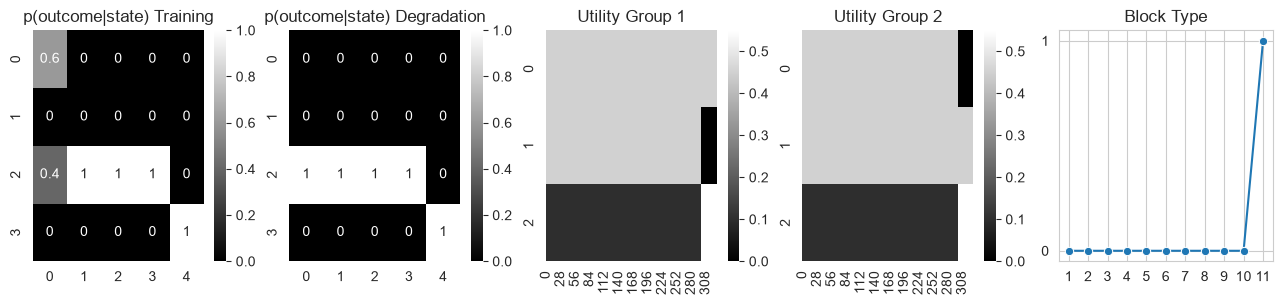

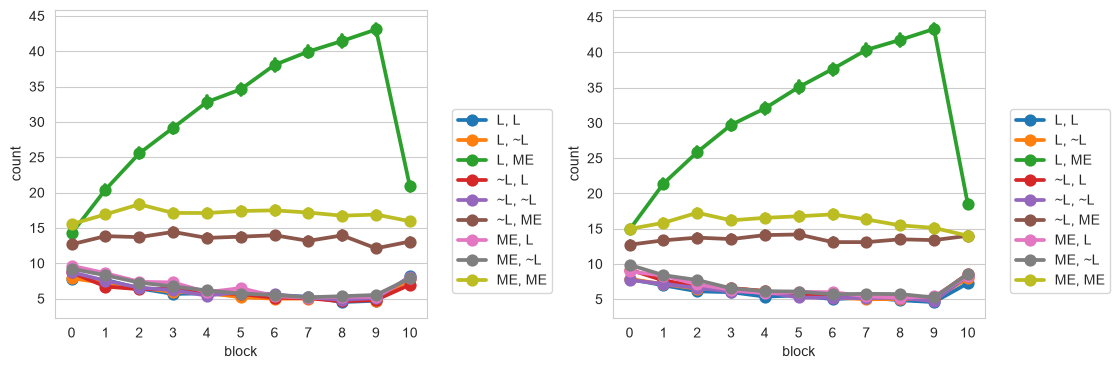

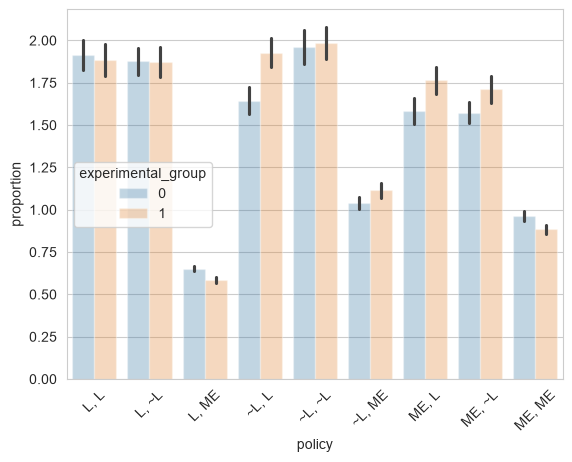

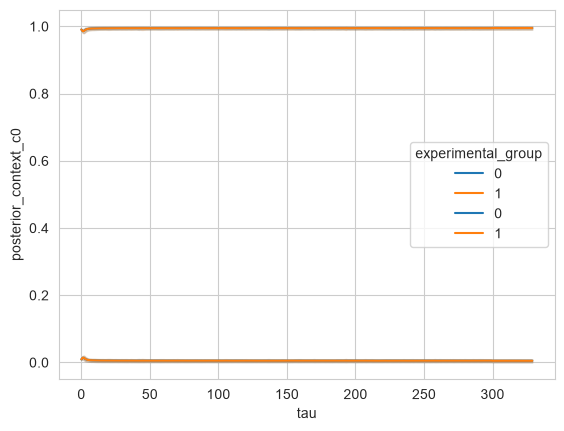

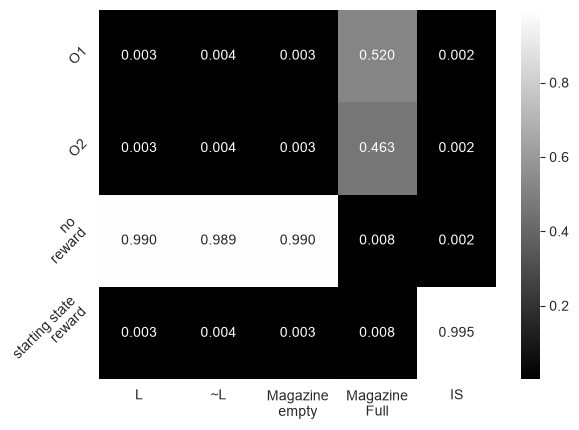

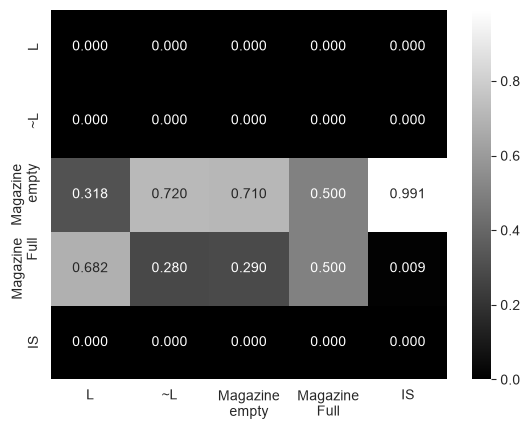

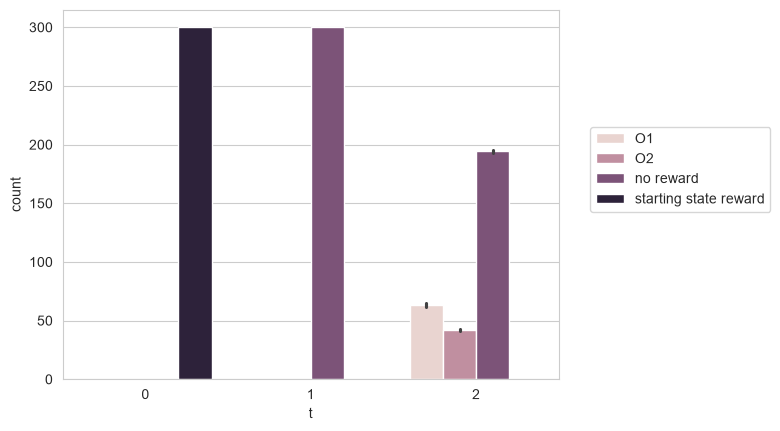

In [21]:
np.random.seed(3)
reps = 200
n_blocks_train = 10
n_blocks_extinction = 1
block_length = 30

n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length
TAU = n_train + n_extinction
T = 3  # initial time point, action 1, action 2
na = 3 # L1, ~L1, magazine entry
ns = 5 # L1, ~L1, empty magazine, full magazine, initial state

p = 0.45
rho_noncontingent = 0.2
rho = 0.6
context_volatility=0.99
h= 10
habit_exception = None


utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]

# outcomes: O1=pellets, O2=sugar, O3= no reward, O4=starting outcome, probably don't really need it
# states: L1, ~L1, magazine entry, initial state in front lever
Rho = np.stack([[[rho  , 0.0, 0.0, 0.0, 0.0],
				 [0    , 0.0, 0.0, 0.0, 0.0],
				 [1-rho, 1.0, 1.0, 1.0, 0.0],
				 [0.0  , 0.0, 0.0, 0.0, 1.0]],
				[[0, 0, 0, 0, 0],
				 [0, 0, 0, 0, 0],
				 [1, 1, 1, 1, 0],
				 [0, 0, 0, 0, 1]]], axis=-1)


long_dfs = []
sim = 0

for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):
   
		world = run_simulation(debug=False, utility=util, na=na, ns=ns, T=T, n_train=n_train, n_extinction=n_extinction,\
							   Rho=Rho, context_volatility=context_volatility,h=h, habit_exception=habit_exception)

		training_protocol = world.environment.training_protocol

		# Create long format dataframe
		long_df = create_dataframe(TAU,T, world)
		long_dfs.append(long_df)

		sim += 1


dataframe = pd.concat(long_dfs)
fig, axes = plt.subplots(1,5,figsize=(16,3))

sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")

sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[2])
sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[3])

sns.lineplot(ax=axes[4], x=np.arange(n_blocks_train + n_blocks_extinction)+1,y=[0]*n_blocks_train + [1]*n_blocks_extinction,marker="o")
axes[4].xaxis.set_major_locator(MultipleLocator(1))
axes[4].yaxis.set_major_locator(MultipleLocator(1))

for ax, title in zip(axes, ["p(outcome|state) Training","p(outcome|state) Degradation", "Utility Group 1", "Utility Group 2", "Block Type"]):
	ax.set_title(title)


# Policy labels
action_labels = ["L", "~L", "ME"]
policy_mapping = []
counter = 0
for i in range(3):
	for j in range(3):
		policy_mapping.append(f"{action_labels[i]}, {action_labels[j]}")

"""	Policy execution in each block for whole experiment """
df = dataframe.copy()
df = df.groupby(["experimental_group","sim","block"])["policy"].value_counts().reset_index()
plt.figure(figsize=(12,4))
for group in [0,1]:
	plt.subplot(1,2,group+1)
	g = sns.pointplot(data=df.query(f"experimental_group == {group}"), x="block", y="count", hue="policy", palette="tab10", errorbar="se")
	g.legend(handles=g.get_legend_handles_labels()[0], labels=policy_mapping, bbox_to_anchor=(1.05,0.7))
plt.subplots_adjust(wspace=0.5)




""""    Relative policy execution in two groups"""
df = dataframe.copy()
df = df.groupby(["experimental_group","sim","phase"])["policy"].value_counts(normalize=True)
relative_policy_frequency = (df.loc[:, :, "extinction",:] / df.loc[:, :, "training",:]).reset_index()
# relative_policy_frequency
plt.figure()
g = sns.barplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", errorbar="se", alpha=0.3)
# sns.stripplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", alpha=0.7)
g.xaxis.set_ticklabels(policy_mapping, rotation=45)


"""     Inferred posterior over contexts """

df = dataframe.copy()
plt.figure()
sns.lineplot(data=df, x="tau", y="posterior_context_c0", hue="experimental_group", errorbar="sd")
sns.lineplot(data=df, x="tau", y="posterior_context_c1", hue="experimental_group", errorbar="sd")

"""      Learned reward distribution     """
plt.figure()
g = sns.heatmap(data=matrices["reward_generation_matrix"], annot=True, cmap="gray", fmt=".3f")
# g.set_xlabel.ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
g.yaxis.set_ticklabels(["O1","O2","no\nreward", "starting state\nreward"], rotation=45)
g.xaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])

"""     Learned state transition       	"""
plt.figure()
g = sns.heatmap(matrices["state_transition_matrix"], annot=True, cmap="gray", fmt=".3f")
# g.set_xlabel.ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
# g.yaxis.set_ticklabels(["O1","O2","no\nreward", "starting state\nreward"], rotation=45)
g.xaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
g.yaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])


"""  Gathered rewards  """
df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
plt.figure()
g = sns.barplot(data=df.query("phase=='training'"), x="t", y="count", hue="reward")
g.legend(handles=g.get_legend_handles_labels()[0], labels=["O1","O2","no reward", "starting state reward"], bbox_to_anchor=(1.05,0.7))



# """   Executed action   """
# df = dataframe.groupby(by=["sim", "phase", "t"])["action"].value_counts().reset_index()
# plt.figure()
# g = sns.barplot(data=df.query("phase=='training'"), x="t", y="count", hue="action")
# g.legend(handles=g.get_legend_handles_labels()[0], labels=["L","~L","ME"], bbox_to_anchor=(1.05,0.7))


## Group 2

In [29]:
# %matplotlib widget
import matplotlib.pyplot as plt
# import ipywidgets
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def	 __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 habit_exception = None,
				 learn_state_transitions = True,
				 transitions_to_learn = ["magazine_empty", "magazine_full"]
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.action_mapping = env.action_mapping
		self.reward_mapping = env.reward_mapping
		self.state_mapping = env.state_mapping
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations
		self.habit_exception=habit_exception

		self.state_transition_matrix = state_transition_matrix
		
		self.learn_state_transitions = learn_state_transitions # if learning transitions to some stae
		self.transitions_to_learn = transitions_to_learn       # transitions to what states are being learned
		
		if self.learn_state_transitions:
			self.transition_counts = np.ones([TAU,T, len(self.transitions_to_learn), self.ns, self.nc])
		
		self.latest_transition_counts = self.transition_counts[0,0,:,:,:]
	
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])

		self.observation_generation_matrix = observation_generation_matrix
		self.post_norms = np.zeros([self.TAU, self.T, self.T, self.npi, self.nc])

	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,:]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility


		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u,c])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u,c]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u,c])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):

		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
		
 		# print("\n")
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

				# print(tau,t,pi,c)
				# print(self.fwd_messages[:,:,pi,c])
		joint_post = np.zeros([self.ns, self.ns, self.T-1, self.npi, self.nc])
  
		for tt in range(self.T-1):
			for c in range(self.nc):
				for pi in range(self.npi):
					action = self.policies[pi][tt]
					joint_post[:,:,tt,pi,c] = (self.state_transition_matrix[:,:,action,c]*self.fwd_messages[None,:,tt,pi,c])*\
											 self.bwd_messages[:,None,tt+1,pi,c]*\
											 self.obs_messages[:,None,tt+1,pi,c]*\
											 self.reward_messages[:,None,tt+1,pi,c]*\
											 self.obs_messages[None,:,tt,pi,c]*\
											 self.reward_messages[None,:,tt,pi,c]
					# if (pi == 2) and (t==1):		

		joint_post /= joint_post.sum(axis=(0,1))[None, None,:,:,:]
		# print("here",tau,t)
		# for tt in range(self.T-1):
		# 	for pi in range(self.npi):
		# 			print(tau,tt, pi,0)
		# 			print(joint_post[:,:,tt,pi,0])
		# 			if np.all (np.isnan(joint_post[:,:,tt,pi,0])):
		# 				print("nan detected")

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		# post[:,t,:,:] /= post[:,t,:,:].sum(axis=0)
		self.post_norms[tau,t] = post_norm
		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post, np.nan_to_num(joint_post)
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies


	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		pol_ind = self.linear_ind(self.actions[tau])
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()

		if pol_ind != self.habit_exception: 
			alphas_prime[pol_ind,:] += posterior_context
			
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs_prior_states(self,t,tau,posterior_states, posterior_policies, posterior_context):
	 
		if self.actions[tau,t-1] == self.action_mapping["magazine_entry"]:
			
			indexes = [self.state_mapping[transition] for transition in self.transitions_to_learn]
			post = (posterior_states[:,:,t-1,:,:]*posterior_policies[None,None,:,:]*posterior_context[None,None,None,:]).sum(axis=2)#.transpose(1,0,2)
			self.latest_transition_counts += post[indexes,:]
			self.transition_counts[tau,t] = self.latest_transition_counts.copy()
			state_transition_matrix = self.state_transition_matrix.copy()
			state_transition_matrix[indexes,:,self.action_mapping["magazine_entry"],:] = self.latest_transition_counts
			# state_transition_matrix[indexes,:,self.action_mapping["magazine_entry"],:]  /= self.latest_transition_counts.sum(axis=0)
			state_transition_matrix /= state_transition_matrix.sum(axis=0)
   
			return state_transition_matrix


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states, joint_posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)

		if t > 0 and action == self.action_mapping["magazine_entry"]:

			self.state_transition_matrix = self.update_beliefs_prior_states(t, tau, joint_posterior_states, posterior_policies, posterior_context)

		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")
			# print(self.env.magazine_state)

			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies)#.round(7))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies)#.round(7))
			
			print(f"\nposterior_context:")
			print(posterior_context)#.round(7))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")


	def sample_action(self,t,tau):
		# try:
		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
   
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				 state_mapping  = {"lever_1_press":0, "lever_2_press":1, "no_lever_press":2, "magazine_empty":3, "magazine_full":4, "initial_state":5},
				 action_mapping = {"lever_1_press":0, "lever_2_press":1, "no_lever_press":2, "magazine_entry":3},
				 reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
 				 rho_noncontingent = 0.3,
	 			#  magazine_state_ind = 2,
				#  no_reward_outcome_ind = 2,
				#  noncontingent_outcome_ind = 1,
				):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.ns = self.B.shape[0]
		self.B_magazine_full = state_transition_matrix.copy()
		self.B_magazine_empty = state_transition_matrix.copy()
		# self.B_magazine_empty[2:4,0:2,-1] = np.array([[1,1],[0,0]])
		# self.B_magazine_full[2:4,0:2,-1] = np.array([[0,0],[1,1]])
		self.B_magazine_empty[3:5,:,-1] = np.array([[1]*self.ns,[0]*self.ns])
		self.B_magazine_full[3:5,:,-1]  = np.array([[0]*self.ns,[1]*self.ns])
		# print(self.B_magazine_empty[:,:,-1])
		# print(self.B_magazine_full[:,:,-1])
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.ones([TAU,T],dtype=int)*reward_mapping["no_reward"]
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits
		self.nb = n_bandits

		self.rho_noncontingent = rho_noncontingent
		self.reward_mapping = reward_mapping
		self.state_mapping = state_mapping
		self.action_mapping = action_mapping
		self.reinforcement = np.zeros(TAU)
		self.magazine_state = np.ones([TAU,T], dtype=int)*self.reward_mapping["no_reward"]

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state, action):
		regime = self.training_protocol[tau]		

		reward = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		
		if t == 0:
			# distribute initial state reward
			self.rewards[tau,t] = reward
		else:
			try:
				# load magazine for next trial
				if reward == self.reward_mapping["outcome_1"]:
					self.magazine_state[tau,t+1] = reward
			except:
				pass                                   # ignore if this was last decision point
			
			# if state == self.state_mapping["magazine_entry"]:
			# 	self.rewards[tau,t] = self.magazine_state[tau,t]

			# if entering magazine get available reward, if not, receive no reward
			if action == self.action_mapping["magazine_entry"]:
				self.rewards[tau,t] = self.magazine_state[tau,t]
			else:
				self.rewards[tau,t] = self.reward_mapping["no_reward"]

		# print("\n", tau,t)
		# print(f"action: {action}, state: {state}, reward: {self.rewards[tau,t]}")
		# print(self.magazine_state[tau])
		return self.rewards[tau,t]


	def noncontingent_reinforcement(self,tau):
		regime = self.training_protocol[tau]
		if regime == 0:
			self.reinforcement[tau] = np.random.uniform() <= self.rho_noncontingent

			if self.reinforcement[tau] == 1:
				self.magazine_state[tau,self.T-1] = self.reward_mapping["outcome_2"]


	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action


		if self.magazine_state[tau,t] != self.reward_mapping["no_reward"] and action == self.action_mapping["magazine_entry"]:
			B = self.B_magazine_full
		else:
			B = self.B_magazine_empty
		
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=B[:,self.states[tau, t-1], action])
		
		# if self.states[tau,t] == 2 and self.magazine_state[tau,t] != self.reward_mapping["no_reward"]:
			# print("\n", tau,t)
			# print(f"action: {action}, state: {self.states[tau,t]}, magazine:{self.magazine_state[tau,t]}")
   
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau):
		self.states[tau,0] = self.state_mapping["initial_state"]
		return self.states[tau,0]


class World():


	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr


	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]


	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau)
					self.environment.noncontingent_reinforcement(tau)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state, action)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)


def run_simulation(h=1000, 
				   n_train = 20,
				   n_extinction = 5, 
				#    rep=1, 
				   na=3, 
				   nb=1, 
				   ns=3, 
				#    no=3, 
				   nr=4, 
				   nc=2, 
				   T=2, 
				   approx_pred_pol = True, 
				   approx_pred_rew = True,
				   utility = [[0.45,0.45, 0.01], [0.8, 0.1, 0.1]], #[[0.45,0.45, 0.01], [0.1,0.8, 0.1]],
				   Rho = None, 
				   debug=False, 
				   context_volatility=0.98, habit_exception=None):
	
	TAU = n_train + n_extinction

	'''           define policies            '''
	npi = na**(T-1)
	nb = nb
	# ns = na+1


	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1,c)      '''
	prior_states = np.array([0]*(ns-1) + [1])[:,None]# np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(ns)]*(ns)).transpose([1,0,2])[:,:,:na]
	state_transition_matrix[5:5,:,-1] = 0.5
	state_transition_matrix = np.stack([state_transition_matrix, state_transition_matrix], axis=-1)
	# print(state_transition_matrix.shape)
	# for a in range(na):
	# 	print(state_transition_matrix[:,:,a,0])
	# 	print(state_transition_matrix[:,:,a,1],"\n")

	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.2, size = counts_prior_rewards.shape)


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.99] + [1-0.99]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	training_protocol = [0]*n_train + [1]*n_extinction

	Rho = Rho[:,:,training_protocol]

	utilities =  np.zeros([TAU,nr])
	utilities[:n_train,:-1] = np.array(utility[0])[None, :]
	utilities[n_train:,:-1] = np.array(utility[1])[None, :]

	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix[:,:,:,0],
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = na,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=ns)

	agent = Agent(
			state_transition_matrix,
			utilities,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			habit_exception=habit_exception
			)

	world = World(agent, env)
	world.agent.context_volatility = context_volatility
	world.agent.h = h
	world.simulate_experiment()

	return world 


def create_dataframe(TAU,T,world):
		agent = world.agent
			# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards.flatten()#world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,:T-1] = world.agent.actions
		action_arr = action_arr.flatten()
		policy_arr = np.full((TAU,T), np.nan)
		policy_arr = np.ravel_multi_index(world.agent.actions.T, (na,na)).repeat(T)
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(T)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		reinforcement_arr = world.environment.reinforcement.repeat(T)
		magazine_state_arr = world.environment.magazine_state.flatten()
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surprise_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surprise_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for s in range(agent.ns):
				reward_prior_arr[f"reward_s{s}_c{c}"] = agent.prior_rewards[:,:,1,s,c].flatten()
	
			for pi in range(agent.npi):
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"policy": policy_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			"reinforcement": reinforcement_arr,
			"magazine_state": magazine_state_arr,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surprise_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		return pd.DataFrame(long_df_dict)

    

In [30]:

np.random.seed(3)
reps = 5
n_blocks_train = 10
n_blocks_extinction = 1
block_length = 30

n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length
TAU = n_train + n_extinction
T = 3  # initial time point, action 1, action 2
na = 4 # L1, L2, ~L, magazine entry
ns = 6 # L1, L2, ~L, empty magazine, full magazine, initial state

p = 0.45
# rho_noncontingent = 0.2
rho = 0.6
p_no_reward = 0.2
context_volatility=0.99
h= 1000
habit_exception = None


utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]

# outcomes: O1=pellets, O2=sugar, O3= no reward, O4=starting outcome, probably don't really need it
# states: L1, ~L1, magazine entry, initial state in front lever
Rho = np.stack([[[rho  , 1-rho, 0.0, 0.0, 0.0, 0.0],
				 [0.0  , 0.0  , 0.0, 0.0, 0.0, 0.0],
				 [1-rho, rho  , 1.0, 1.0, 1.0, 0.0],
				 [0.0  , 0.0  , 0.0, 0.0, 0.0, 1.0]],
				[[0, 0, 0, 0, 0, 0],
				 [0, 0, 0, 0, 0, 0],
				 [1, 1, 1, 1, 1, 0],
				 [0, 0, 0, 0, 0, 1]]], axis=-1)


long_dfs = []
sim = 0

for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):
   
		world = run_simulation(debug=False, utility=util, na=na, ns=ns, T=T, n_train=n_train, n_extinction=n_extinction,\
							   Rho=Rho, context_volatility=context_volatility,h=h, habit_exception=habit_exception)

		training_protocol = world.environment.training_protocol

		# Create long format dataframe
		long_df = create_dataframe(TAU,T, world)
		long_dfs.append(long_df)

		sim += 1


dataframe = pd.concat(long_dfs)
fig, axes = plt.subplots(1,5,figsize=(16,3))

sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")

sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[2])
sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[3])

sns.lineplot(ax=axes[4], x=np.arange(n_blocks_train + n_blocks_extinction)+1,y=[0]*n_blocks_train + [1]*n_blocks_extinction,marker="o")
axes[4].xaxis.set_major_locator(MultipleLocator(1))
axes[4].yaxis.set_major_locator(MultipleLocator(1))

for ax, title in zip(axes, ["p(outcome|state) Training","p(outcome|state) Degradation", "Utility Group 1", "Utility Group 2", "Block Type"]):
	ax.set_title(title)


# Policy labels
action_labels = ["L1", "L2","~L", "ME"]
policy_mapping = []
counter = 0
for i in range(3):
	for j in range(3):
		policy_mapping.append(f"{action_labels[i]}, {action_labels[j]}")

"""	Policy execution in each block for whole experiment """
df = dataframe.copy()
df = df.groupby(["experimental_group","sim","block"])["policy"].value_counts().reset_index()
plt.figure(figsize=(12,4))
for group in [0,1]:
	plt.subplot(1,2,group+1)
	g = sns.pointplot(data=df.query(f"experimental_group == {group}"), x="block", y="count", hue="policy", palette="tab10", errorbar="se")
	g.legend(handles=g.get_legend_handles_labels()[0], labels=policy_mapping, bbox_to_anchor=(1.05,0.7))
plt.subplots_adjust(wspace=0.5)




""""    Relative policy execution in two groups"""
df = dataframe.copy()
df = df.groupby(["experimental_group","sim","phase"])["policy"].value_counts(normalize=True)
relative_policy_frequency = (df.loc[:, :, "extinction",:] / df.loc[:, :, "training",:]).reset_index()
# relative_policy_frequency
plt.figure()
g = sns.barplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", errorbar="se", alpha=0.3)
# sns.stripplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", alpha=0.7)
g.xaxis.set_ticklabels(policy_mapping, rotation=45)


"""     Inferred posterior over contexts """

df = dataframe.copy()
plt.figure()
sns.lineplot(data=df, x="tau", y="posterior_context_c0", hue="experimental_group", errorbar="sd")
sns.lineplot(data=df, x="tau", y="posterior_context_c1", hue="experimental_group", errorbar="sd")

"""      Learned reward distribution     """
plt.figure()
g = sns.heatmap(data=matrices["reward_generation_matrix"], annot=True, cmap="gray", fmt=".3f")
# g.set_xlabel.ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
g.yaxis.set_ticklabels(["O1","O2","no\nreward", "starting state\nreward"], rotation=45)
g.xaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])

"""     Learned state transition       	"""
plt.figure()
g = sns.heatmap(matrices["state_transition_matrix"], annot=True, cmap="gray", fmt=".3f")
# g.set_xlabel.ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
# g.yaxis.set_ticklabels(["O1","O2","no\nreward", "starting state\nreward"], rotation=45)
g.xaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])
g.yaxis.set_ticklabels(["L","~L","Magazine\nempty","Magazine\nFull","IS"])


"""  Gathered rewards  """
df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
plt.figure()
g = sns.barplot(data=df.query("phase=='training'"), x="t", y="count", hue="reward")
g.legend(handles=g.get_legend_handles_labels()[0], labels=["O1","O2","no reward", "starting state reward"], bbox_to_anchor=(1.05,0.7))



# """   Executed action   """
# df = dataframe.groupby(by=["sim", "phase", "t"])["action"].value_counts().reset_index()
# plt.figure()
# g = sns.barplot(data=df.query("phase=='training'"), x="t", y="count", hue="action")
# g.legend(handles=g.get_legend_handles_labels()[0], labels=["L","~L","ME"], bbox_to_anchor=(1.05,0.7))


ValueError: probabilities contain NaN